In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
diccionario = pd.read_excel('Diccionario_Variables_Alumnos.xlsx')
diccionario.head(19)

,Variables,Descripción,Valores
0,ID,Identificador único del préstamo.,Código identificador del cliente.
1,Edad,Edad del prestatario.,Valor numérico.
2,Ingresos,Ingreso anual del prestatario.,Valor numérico.
3,Monto_Inicial,Cantidad de dinero acordada.,Valor numérico.
4,Scoring_Crediticio,"La puntuación crediticia del prestatario, que ...",Valor numérico.
5,Meses_Empleo,Meses de vida laboral del prestatario.,Valor numérico.
6,Num_Creditos,Número de líneas de credito abiertas del prest...,Valor numérico.
7,Ratio_Interes,El ratio de interés del préstamo (multiplicado...,Valor numérico.
8,Duracion,La duración del prestamo en meses.,Valor numérico.
9,Ratio_Deuda_Ingresos,"Ratio de deuda frente a ingresos, que indica l...",Valor numérico.


In [35]:
diccionario.shape

(19, 3)

In [36]:
prestamos = pd.read_excel('Prestamos_Data_Alumnos_v5.xlsx')
prestamos.head()

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Estudios,Tipo_Jornada_Laboral,Estado_Civil,Posesion_Hipoteca,Personas_Cargo,Proposito,Fiador,Impago,Prima
0,O77MPJ,26,19153.0,6973,706,9.0,1,19.05,36.0,0.10,Grado Universitario,Jornada completa,Soltero,0.0,1.0,Automóvil,1.0,1,130.83
1,6B4H6E,22,16000.0,10000,769,22.0,1,8.96,48.0,0.32,Escolar,Desempleado,Soltero,1.0,1.0,Vivienda,0.0,0,65.85
2,VKTUXP,33,38308.0,16474,699,70.0,3,14.07,36.0,0.20,Máster,Jornada completa,Casado,1.0,1.0,Vivienda,0.0,0,260.60
3,5P9OVL,51,51271.0,40770,812,309.0,1,12.66,12.0,0.36,Grado Universitario,Jornada completa,Casado,0.0,1.0,Vivienda,1.0,0,221.02
4,KG9CT9,34,56572.0,73978,763,86.0,1,13.91,60.0,0.55,Máster,Tiempo parcial,Soltero,0.0,0.0,Educación,0.0,0,800.00


# Limpieza y análisis descriptivo

In [37]:
prestamos = prestamos[prestamos["Proposito"] == "Educación"].copy()

print("Dimensiones de la muestra:", prestamos.shape)

Dimensiones de la muestra: (178609, 19)


In [38]:
prestamos = prestamos.drop(columns=["Proposito"]) # la variable ya no aporta información nueva

In [39]:
prestamos.head()

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Estudios,Tipo_Jornada_Laboral,Estado_Civil,Posesion_Hipoteca,Personas_Cargo,Fiador,Impago,Prima
4,KG9CT9,34,56572.0,73978,763,86.0,1,13.91,60.0,0.55,Máster,Tiempo parcial,Soltero,0.0,0.0,0.0,0,800.00
5,V5O0K9,37,68698.0,150000,824,162.0,2,10.53,24.0,0.37,Máster,Jornada completa,Casado,1.0,0.0,0.0,0,580.00
6,YE5GD0,40,50000.0,7490,671,167.0,2,9.24,60.0,0.10,Grado Universitario,Autónomo,Casado,1.0,1.0,0.0,0,130.00
11,Q6HQ3D,38,63033.0,11801,649,196.0,1,7.63,48.0,0.10,Grado Universitario,Tiempo parcial,Soltero,0.0,1.0,0.0,0,168.08
12,XO8CO4,19,22301.0,40000,788,17.0,4,8.40,36.0,0.50,Escolar,Jornada completa,Soltero,1.0,1.0,1.0,0,293.94


In [40]:
prestamos.shape

(178609, 18)

In [41]:
prestamos.info()

<class 'pandas.DataFrame'>
Index: 178609 entries, 4 to 510702
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    178609 non-null  str    
 1   Edad                  178609 non-null  int64  
 2   Ingresos              178609 non-null  float64
 3   Monto_Inicial         178609 non-null  int64  
 4   Scoring_Crediticio    178609 non-null  int64  
 5   Meses_Empleo          178609 non-null  float64
 6   Num_Creditos          178609 non-null  int64  
 7   Ratio_Interes         178608 non-null  float64
 8   Duracion              178609 non-null  float64
 9   Ratio_Deuda_Ingresos  178609 non-null  float64
 10  Estudios              178608 non-null  str    
 11  Tipo_Jornada_Laboral  178609 non-null  str    
 12  Estado_Civil          178609 non-null  str    
 13  Posesion_Hipoteca     178609 non-null  float64
 14  Personas_Cargo        178609 non-null  float64
 15  Fiador          

In [42]:
prestamos.describe()

,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Posesion_Hipoteca,Personas_Cargo,Fiador,Impago,Prima
count,178609.000000,178609.000000,178609.000000,178609.000000,178609.000000,178609.000000,178608.000000,178609.000000,178609.000000,178609.000000,178609.000000,178609.000000,178609.000000,178609.000000
mean,39.647828,41509.990101,45190.162237,692.052310,212.771288,2.001036,10.676223,37.255569,0.321930,0.348980,0.450280,0.299475,0.116316,386.804304
std,10.076916,16036.686852,46647.925592,87.828291,150.688879,1.001295,3.809248,14.166742,0.181164,0.476649,0.497523,0.458030,0.320604,267.648661
min,19.000000,16000.000000,3000.000000,398.000000,0.000000,1.000000,2.010000,12.000000,0.100000,0.000000,0.000000,0.000000,0.000000,10.000000
25%,33.000000,30484.000000,15125.000000,635.000000,70.000000,1.000000,7.960000,24.000000,0.140000,0.000000,0.000000,0.000000,0.000000,138.880000
50%,39.000000,39090.000000,40000.000000,704.000000,208.000000,2.000000,10.590000,36.000000,0.290000,0.000000,0.000000,0.000000,0.000000,340.090000
75%,46.000000,50097.000000,47625.000000,761.000000,336.000000,3.000000,13.270000,48.000000,0.550000,1.000000,1.000000,1.000000,0.000000,621.670000
max,64.000000,120000.000000,400000.000000,845.000000,639.000000,4.000000,24.440000,60.000000,0.550000,1.000000,1.000000,1.000000,1.000000,800.000000


## Tipos de columnas

In [43]:
# las columnas 'Posesion_Hipoteca', 'Personas_Cargo' y 'Fiador' están en float y hay que pasarlas a int porque son categorías binarias, es decir, es 0 o 1.
prestamos['Posesion_Hipoteca'] = prestamos['Posesion_Hipoteca'].astype(int)
prestamos['Personas_Cargo'] = prestamos['Personas_Cargo'].astype(int)
prestamos['Fiador'] = prestamos['Fiador'].astype(int)

In [44]:
# las columna 'Duracion' y 'Meses_Empleo' también hay que pasarla a int porque la duración está en meses, y no tiene decimales
prestamos['Duracion'] = prestamos['Duracion'].astype(int)
prestamos['Meses_Empleo'] = prestamos['Meses_Empleo'].astype(int)

In [45]:
# La columna 'Ingresos' también hay que ponerla en int porque no tiene decimales
prestamos['Ingresos'] = prestamos['Ingresos'].astype(int)

In [46]:
prestamos.head()

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Estudios,Tipo_Jornada_Laboral,Estado_Civil,Posesion_Hipoteca,Personas_Cargo,Fiador,Impago,Prima
4,KG9CT9,34,56572,73978,763,86,1,13.91,60,0.55,Máster,Tiempo parcial,Soltero,0,0,0,0,800.00
5,V5O0K9,37,68698,150000,824,162,2,10.53,24,0.37,Máster,Jornada completa,Casado,1,0,0,0,580.00
6,YE5GD0,40,50000,7490,671,167,2,9.24,60,0.10,Grado Universitario,Autónomo,Casado,1,1,0,0,130.00
11,Q6HQ3D,38,63033,11801,649,196,1,7.63,48,0.10,Grado Universitario,Tiempo parcial,Soltero,0,1,0,0,168.08
12,XO8CO4,19,22301,40000,788,17,4,8.40,36,0.50,Escolar,Jornada completa,Soltero,1,1,1,0,293.94


In [47]:
prestamos.dtypes

ID                          str
Edad                      int64
Ingresos                  int64
Monto_Inicial             int64
Scoring_Crediticio        int64
Meses_Empleo              int64
Num_Creditos              int64
Ratio_Interes           float64
Duracion                  int64
Ratio_Deuda_Ingresos    float64
Estudios                    str
Tipo_Jornada_Laboral        str
Estado_Civil                str
Posesion_Hipoteca         int64
Personas_Cargo            int64
Fiador                    int64
Impago                    int64
Prima                   float64
dtype: object

## Nulos y duplicados

In [48]:
prestamos.isna().sum() # solo hay dos nulos en todo el dataset. El dataset es muy grande, por lo tanto, hemos decidido borrar las filas que contienen los nulos ya que el impacto de eliminarlas es muy pequeño.

ID                      0
Edad                    0
Ingresos                0
Monto_Inicial           0
Scoring_Crediticio      0
Meses_Empleo            0
Num_Creditos            0
Ratio_Interes           1
Duracion                0
Ratio_Deuda_Ingresos    0
Estudios                1
Tipo_Jornada_Laboral    0
Estado_Civil            0
Posesion_Hipoteca       0
Personas_Cargo          0
Fiador                  0
Impago                  0
Prima                   0
dtype: int64

In [49]:
prestamos = prestamos.dropna()

In [50]:
print("Número de filas:", len(prestamos))
print("Número de ID únicos:", prestamos["ID"].nunique())
print("ID duplicados:", prestamos["ID"].duplicated().sum())    # no hay ningún id duplicado, todos son únicos

Número de filas: 178607
Número de ID únicos: 178606
ID duplicados: 1


In [51]:
prestamos.duplicated().sum() # solo hay un duplicado, por lo que eliminamos la fila tambien

np.int64(1)

In [52]:
prestamos = prestamos.drop_duplicates()

# EDA

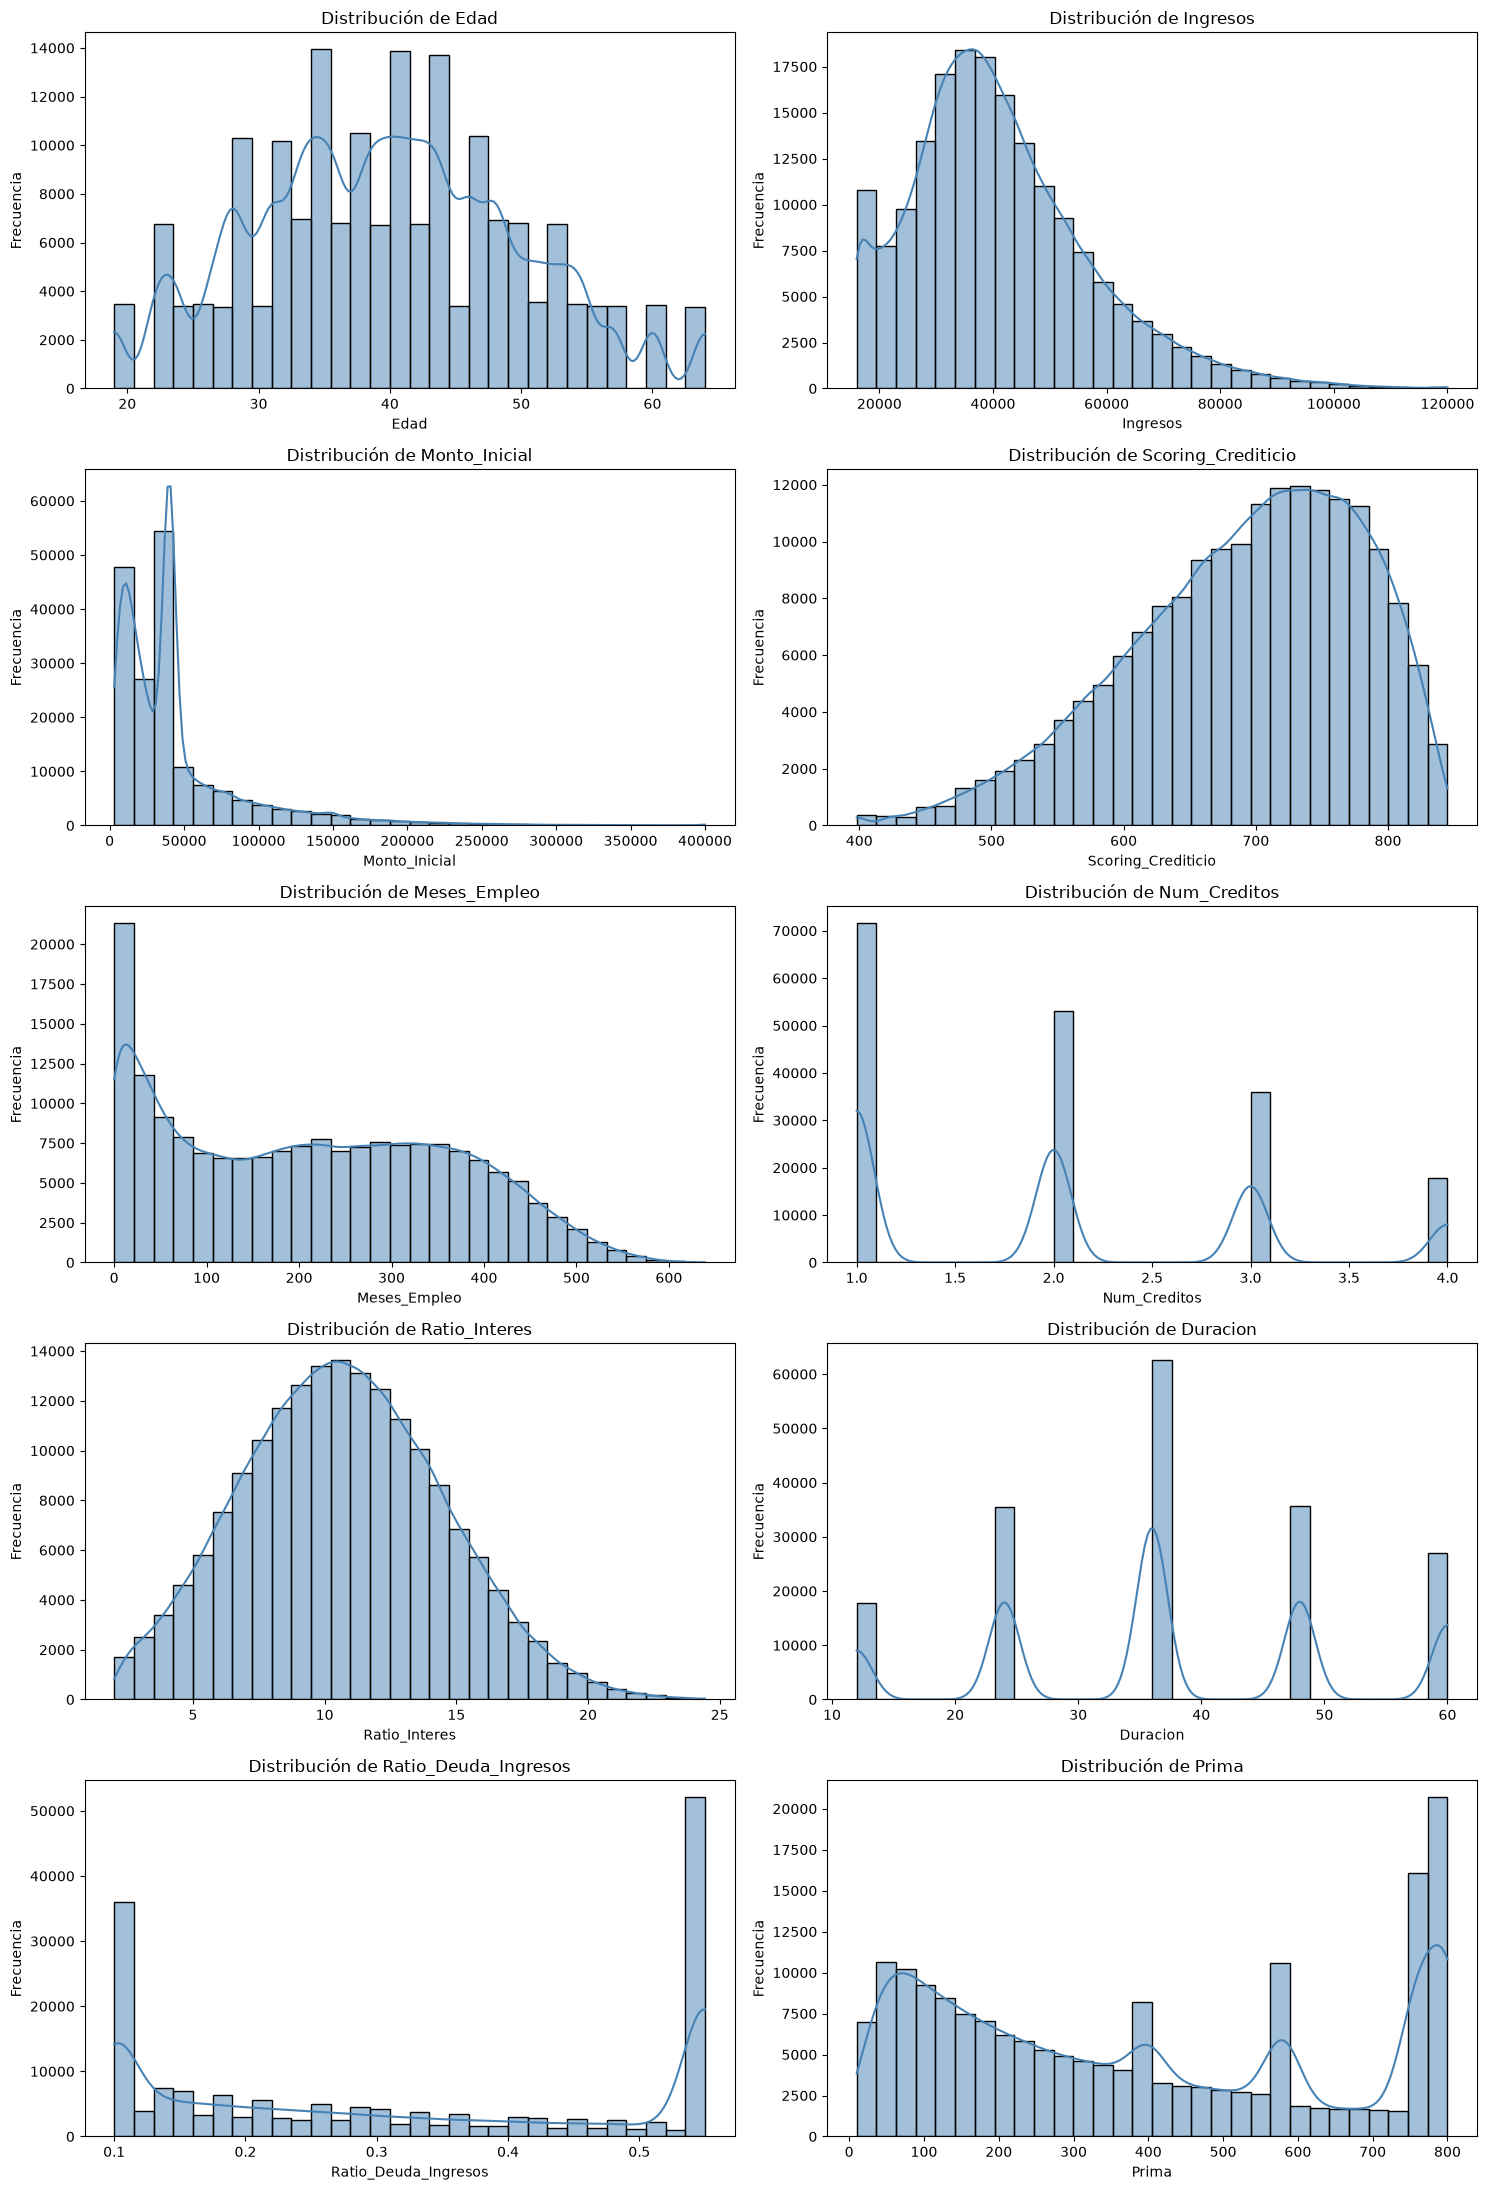

In [53]:
# Histogramas de varibales numéricas
columnas_numericas = [
    "Edad",
    "Ingresos",
    "Monto_Inicial",
    "Scoring_Crediticio",
    "Meses_Empleo",
    "Num_Creditos",
    "Ratio_Interes",
    "Duracion",
    "Ratio_Deuda_Ingresos",
    "Prima"
]

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(15, 22)
)

axes = axes.flatten()

for i, columna in enumerate(columnas_numericas):
    sns.histplot(
        data=prestamos,
        x=columna,
        bins=30,
        kde=True,
        ax=axes[i],
        color="steelblue"
    )

    axes[i].set_title(f"Distribución de {columna}")
    axes[i].set_xlabel(columna)
    axes[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

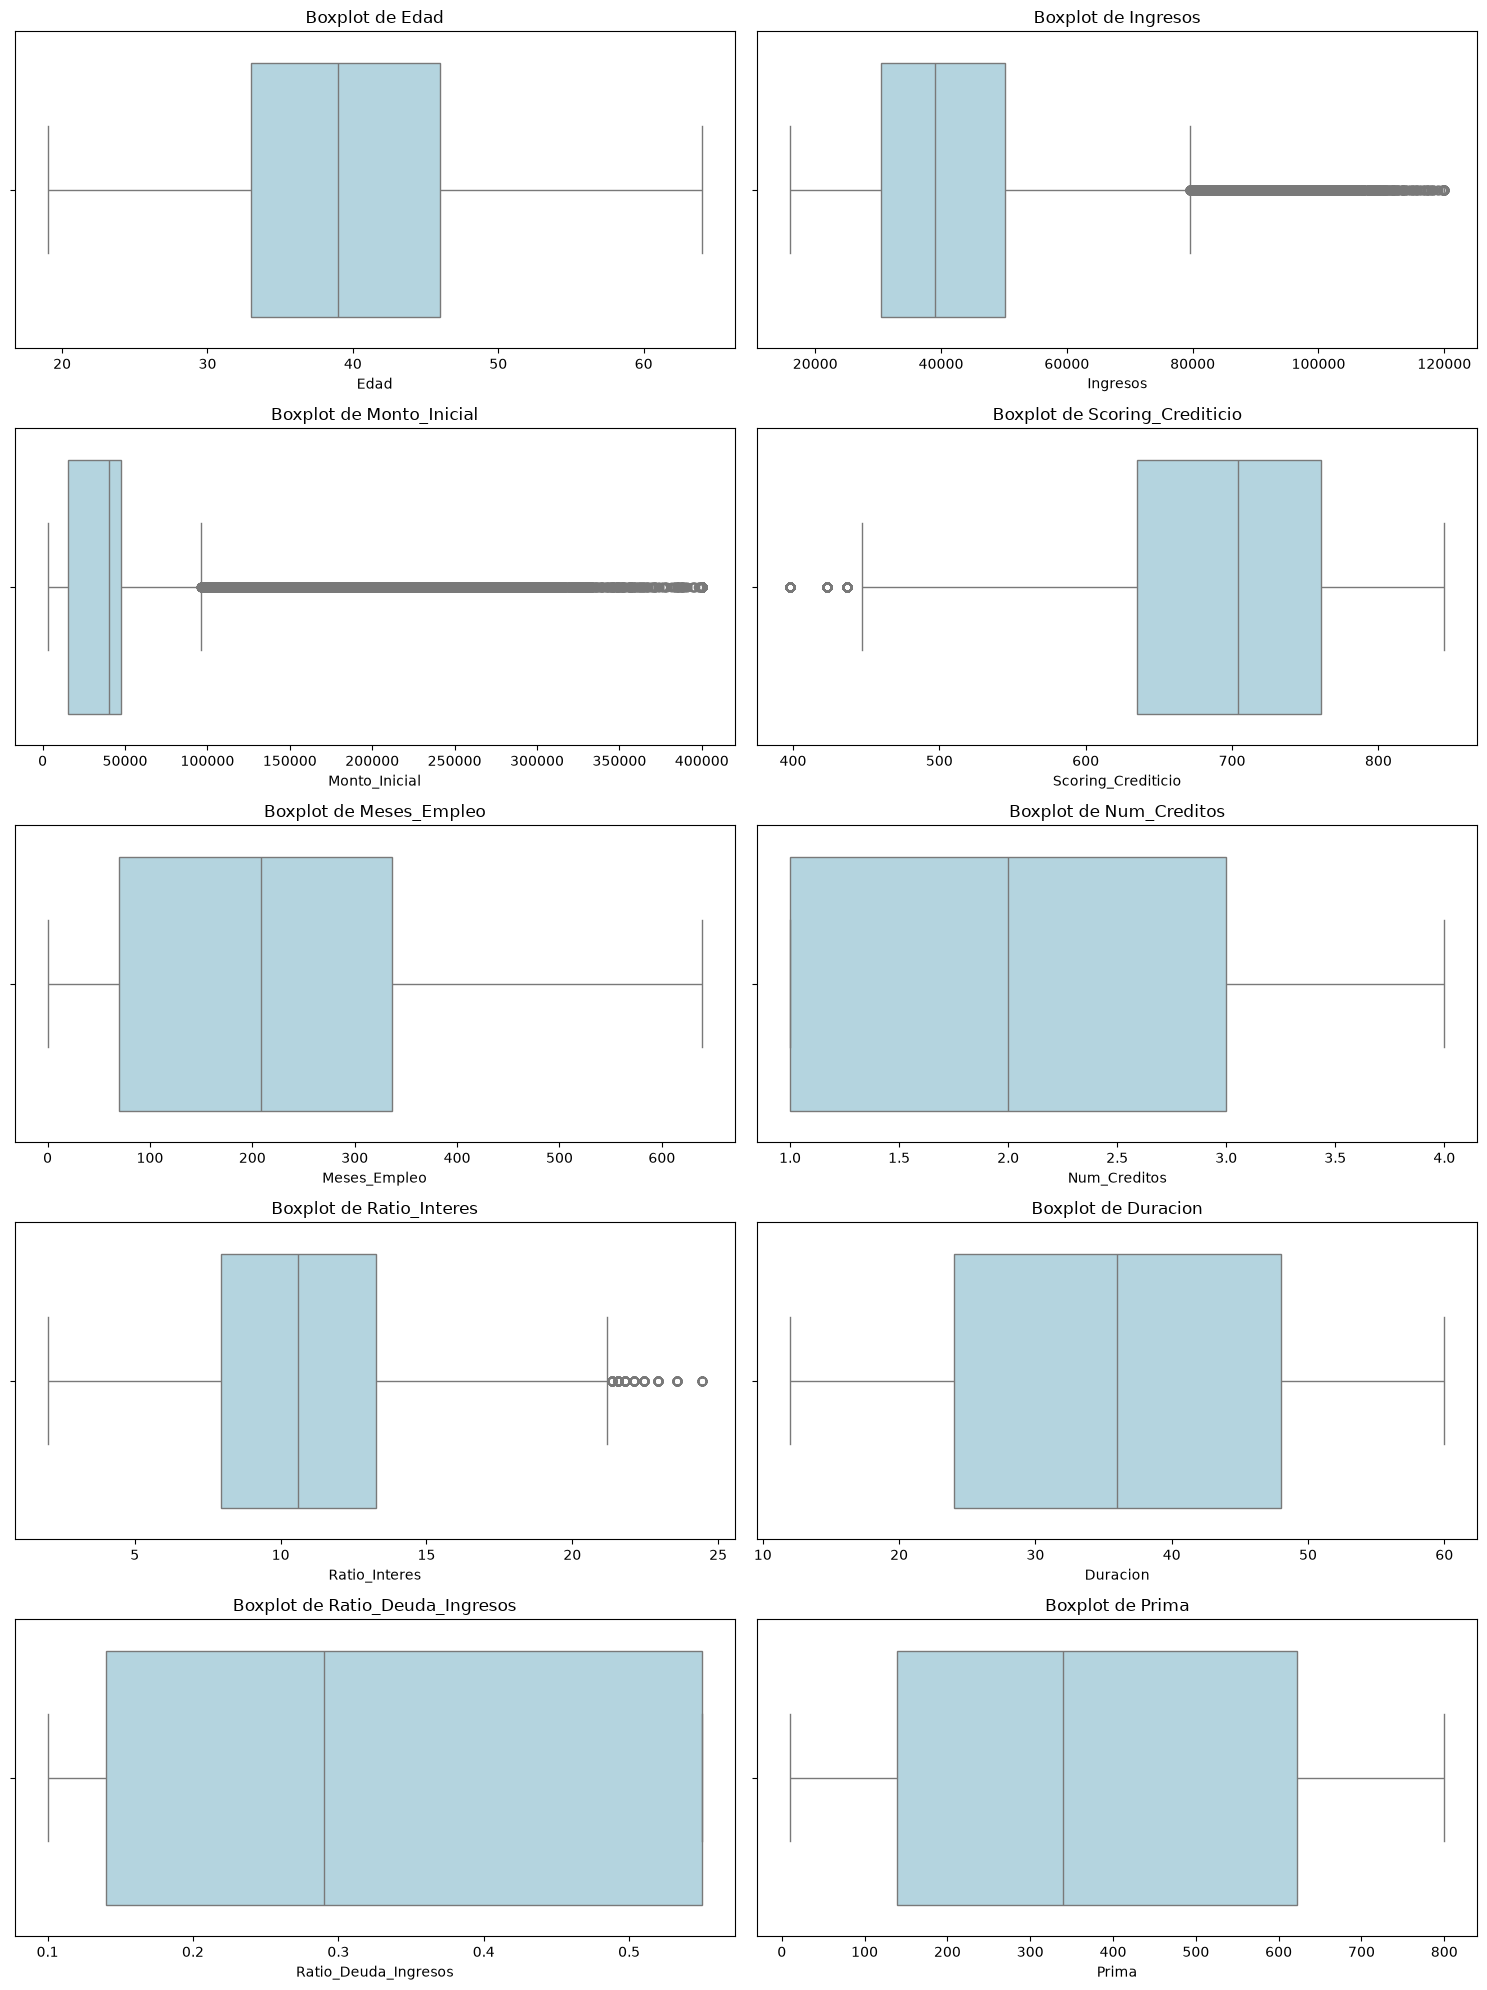

In [54]:
# Boxplots para observar valores atípicos
fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(15, 20)
)

axes = axes.flatten()

for i, columna in enumerate(columnas_numericas):
    sns.boxplot(
        data=prestamos,
        x=columna,
        ax=axes[i],
        color="lightblue"
    )

    axes[i].set_title(f"Boxplot de {columna}")
    axes[i].set_xlabel(columna)

plt.tight_layout()
plt.show()


##### En los boxplots se observan valores atípicos en Ingresos y Monto_Inicial. Se decide dejarlos tal cual están: son variables económicas con una distribución naturalmente asimétrica (la mayoría de personas tiene ingresos y préstamos moderados, pero un número menor de casos con valores altos es normal, no un error de los datos), y esos valores altos son precisamente los más relevantes para estimar el riesgo y el coste del seguro, que es el objetivo del reto.

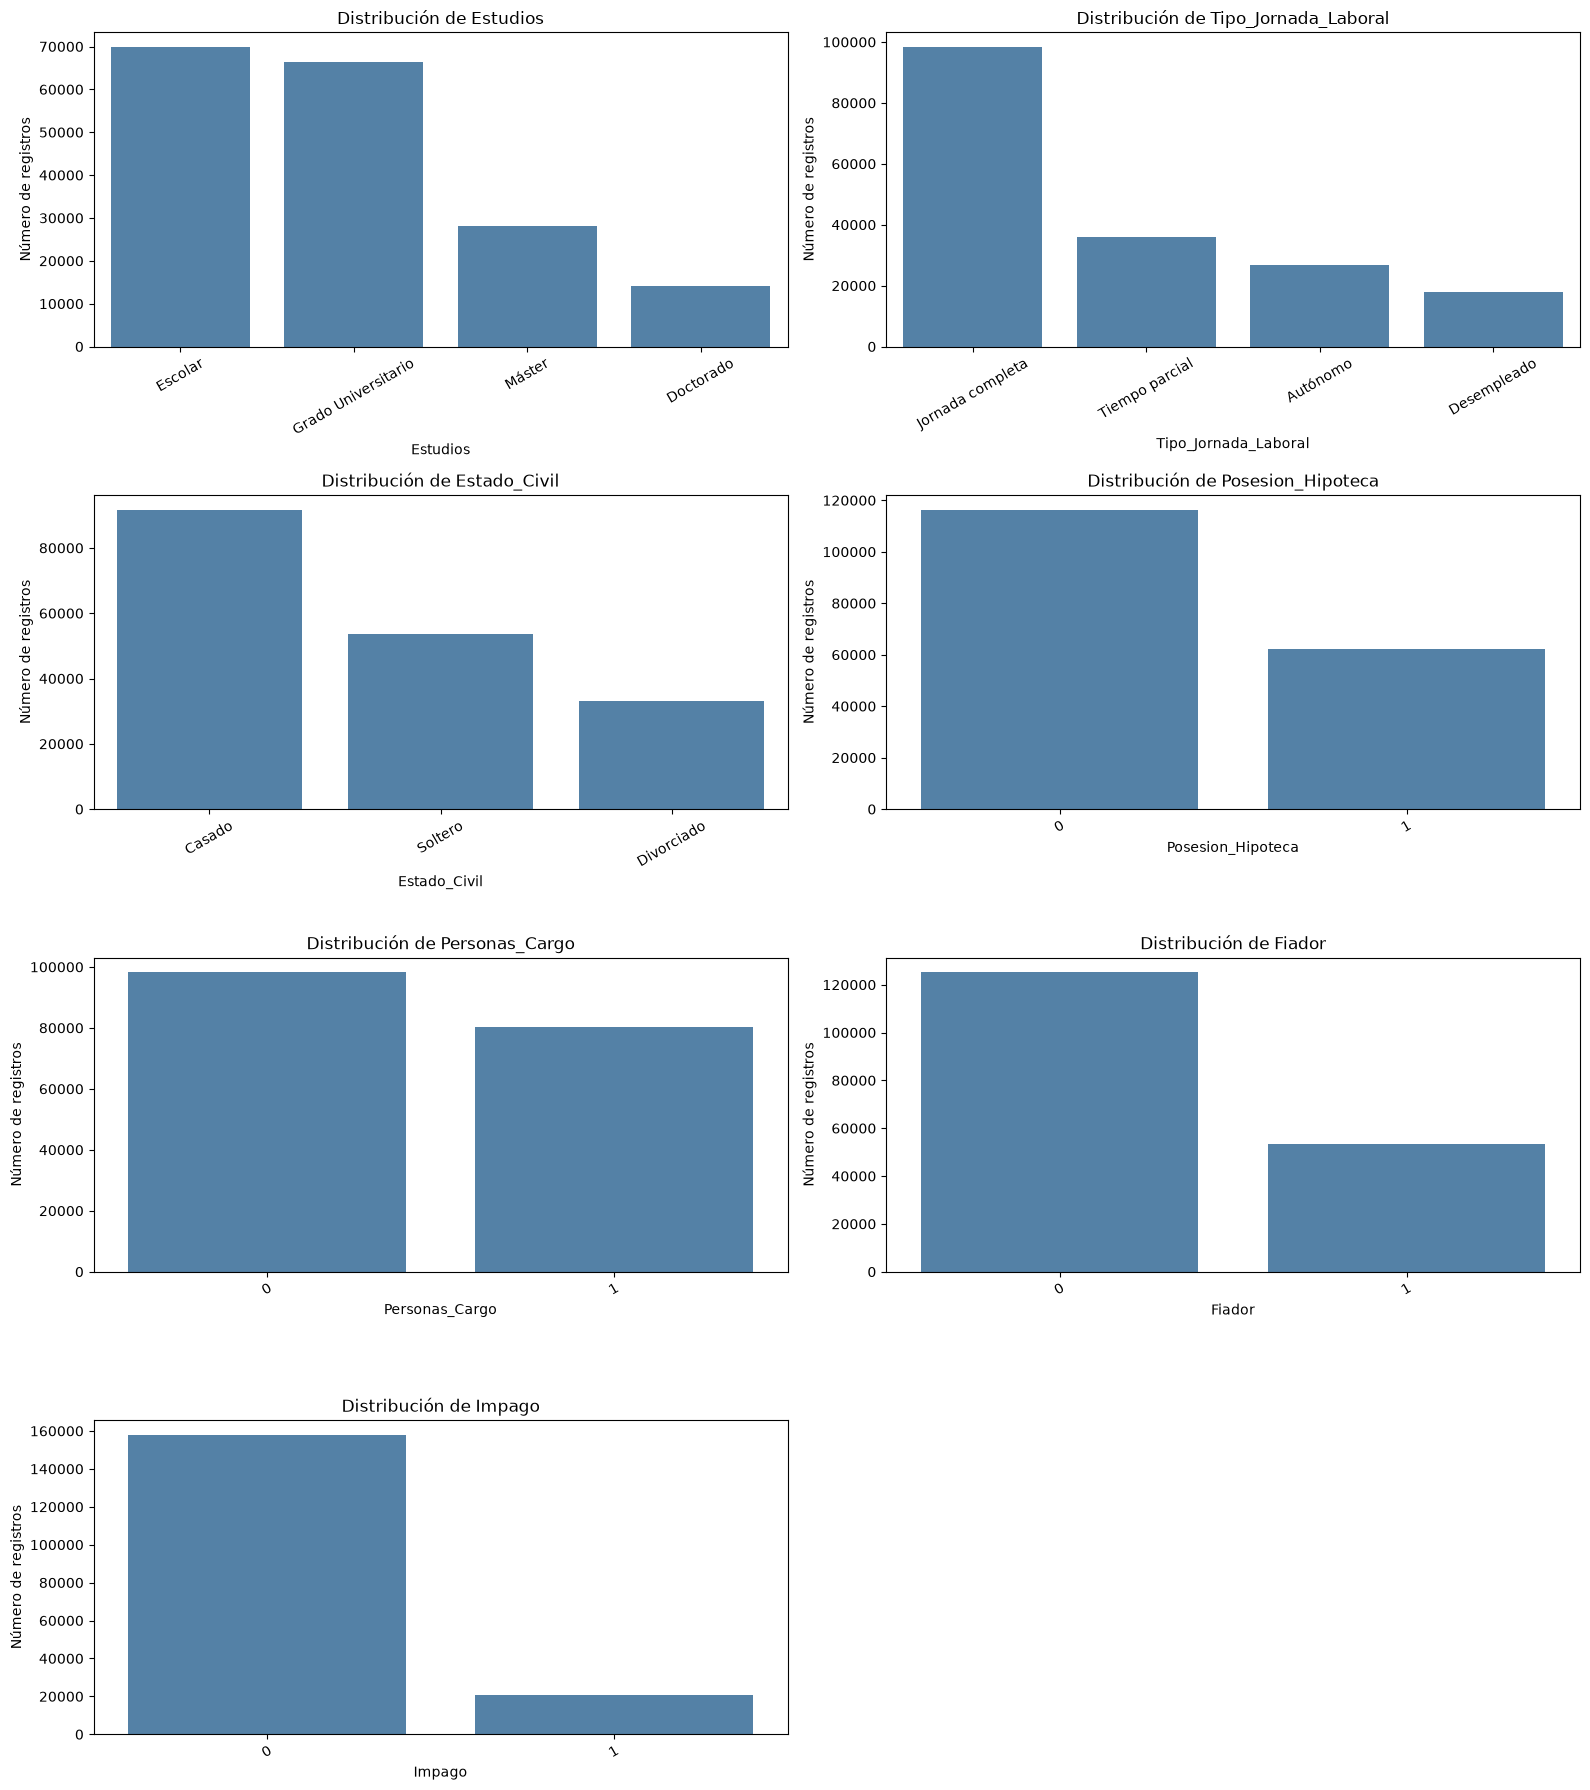

In [55]:
# Distribución de varibales categóricas
columnas_categoricas = [
    "Estudios",
    "Tipo_Jornada_Laboral",
    "Estado_Civil",
    "Posesion_Hipoteca",
    "Personas_Cargo",
    "Fiador",
    "Impago"
]

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(16, 18)
)

axes = axes.flatten()

for i, columna in enumerate(columnas_categoricas):
    orden = prestamos[columna].value_counts().index

    sns.countplot(
        data=prestamos,
        x=columna,
        order=orden,
        ax=axes[i],
        color="steelblue"
    )

    axes[i].set_title(f"Distribución de {columna}")
    axes[i].set_xlabel(columna)
    axes[i].set_ylabel("Número de registros")
    axes[i].tick_params(axis="x", rotation=30)

# Ocultar el octavo espacio, porque solamente hay siete variables
axes[7].set_visible(False)

plt.tight_layout()
plt.show()

In [56]:
for columna in columnas_categoricas:
    resumen = pd.DataFrame({
        "Frecuencia": prestamos[columna].value_counts(),
        "Porcentaje": (
            prestamos[columna]
            .value_counts(normalize=True)
            .mul(100)
            .round(2)
        )
    })

    print(f"\n{columna}")
    display(resumen)


Estudios


,Frecuencia,Porcentaje
Estudios,,
Escolar,69816,39.09
Grado Universitario,66497,37.23
Máster,28091,15.73
Doctorado,14202,7.95



Tipo_Jornada_Laboral


,Frecuencia,Porcentaje
Tipo_Jornada_Laboral,,
Jornada completa,98260,55.01
Tiempo parcial,35814,20.05
Autónomo,26735,14.97
Desempleado,17797,9.96



Estado_Civil


...

,Frecuencia,Porcentaje
Personas_Cargo,,
0,98183,54.97
1,80423,45.03



Fiador


,Frecuencia,Porcentaje
Fiador,,
0,125117,70.05
1,53489,29.95



Impago


,Frecuencia,Porcentaje
Impago,,
0,157832,88.37
1,20774,11.63


# Preprocesamiento para el modelado

## Codificación de variables categóricas

### Codificación ordinal

In [57]:
prestamos['Estudios'].unique()

<StringArray>
['Máster', 'Grado Universitario', 'Escolar', 'Doctorado']
Length: 4, dtype: str

In [58]:
# en el caso de la columna 'Educación', vamos a hacer una codificación ordinal, ya que las categorias tienen un orden educativo real. Cuanto más formación tengan, el número va a ser más alto.
orden_estudios = {
    "Escolar": 0,
    "Grado Universitario": 1,
    "Máster": 2,
    "Doctorado": 3
}

prestamos["Estudios"] = prestamos["Estudios"].str.strip()
prestamos["Estudios_encoded"] = prestamos["Estudios"].map(orden_estudios)

print(prestamos[["Estudios", "Estudios_encoded"]].value_counts())

Estudios             Estudios_encoded
Escolar              0                   69816
Grado Universitario  1                   66497
Máster               2                   28091
Doctorado            3                   14202
Name: count, dtype: int64


### "Estudios" ya no aporta información nueva una vez creada "Estudios_encoded" , así que se elimina.

In [59]:
prestamos = prestamos.drop(columns=["Estudios"])

In [60]:
prestamos['Estado_Civil'].unique()

<StringArray>
['Soltero', 'Casado', 'Divorciado']
Length: 3, dtype: str

### Codificación one-hot

In [61]:
# Para que sea mas efectivo para los modelos posteriores, hemos decidido hacer un One Hot Enconding en las variable 'Estado_Civil' y 'Tipo_Jornada_Laboral' para binarizar las variabales
prestamos["Estado_Civil"] = prestamos["Estado_Civil"].str.strip().str.capitalize()
prestamos = pd.get_dummies(prestamos, columns=["Estado_Civil"], dtype=int, drop_first=True)

In [62]:
prestamos['Tipo_Jornada_Laboral'].unique()

<StringArray>
['Tiempo parcial', 'Jornada completa', 'Autónomo', 'Desempleado']
Length: 4, dtype: str

In [63]:
prestamos["Tipo_Jornada_Laboral"] = prestamos["Tipo_Jornada_Laboral"].str.strip().str.capitalize()
prestamos = pd.get_dummies(prestamos, columns=["Tipo_Jornada_Laboral"], dtype=int, drop_first=True)

In [64]:
prestamos.head()

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,...,Personas_Cargo,Fiador,Impago,Prima,Estudios_encoded,Estado_Civil_Divorciado,Estado_Civil_Soltero,Tipo_Jornada_Laboral_Desempleado,Tipo_Jornada_Laboral_Jornada completa,Tipo_Jornada_Laboral_Tiempo parcial
4,KG9CT9,34,56572,73978,763,86,1,13.91,60,0.55,...,0,0,0,800.00,2,0,1,0,0,1
5,V5O0K9,37,68698,150000,824,162,2,10.53,24,0.37,...,0,0,0,580.00,2,0,0,0,1,0
6,YE5GD0,40,50000,7490,671,167,2,9.24,60,0.10,...,1,0,0,130.00,1,0,0,0,0,0
11,Q6HQ3D,38,63033,11801,649,196,1,7.63,48,0.10,...,1,0,0,168.08,1,0,1,0,0,1
12,XO8CO4,19,22301,40000,788,17,4,8.40,36,0.50,...,1,1,0,293.94,0,0,1,0,1,0


### Correlación de las variables numéricas con las variables objetivo

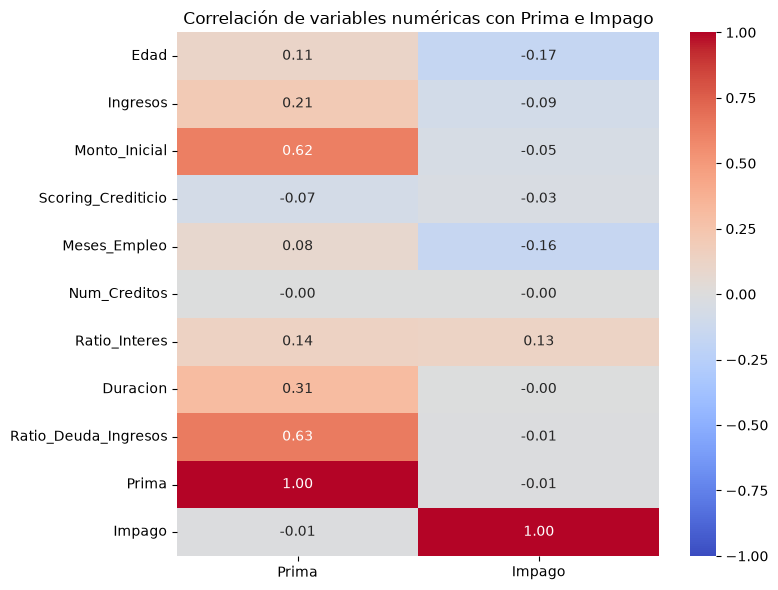

In [65]:
columnas_correlacion = columnas_numericas + ["Impago"]

matriz_correlacion = prestamos[columnas_correlacion].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_correlacion[["Prima", "Impago"]],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("Correlación de variables numéricas con Prima e Impago")
plt.tight_layout()
plt.show()